# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/riteshy1526/flyrank-internship-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

### Ranked actions and reason codes

The action queue prioritizes content pages for human review using the validated model output and observable content signals.

Each page receives a priority score and a human-readable reason code. The reason code explains the main signal behind the recommendation, such as stale content, declining traffic, low CTR, or a combination of opportunity signals.

The ranking is a prioritization aid. A higher score means that the page should be reviewed earlier; it does not guarantee that refreshing the page will improve performance.

In [15]:
# Section 1: Load data and create the action queue

import os
import numpy as np
import pandas as pd

DATA_PATH = "../../data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

# ---------------------------------------------------------
# Build transparent refresh-priority signals
# ---------------------------------------------------------

required_cols = [
    "content_id",
    "search_volume",
    "ctr",
    "content_age_days",
    "days_since_last_update",
    "trend_pct"
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

assert not missing_cols, f"Missing columns: {missing_cols}"

# Percentile-based signals make different units comparable.
df["staleness_signal"] = (
    0.60 * df["days_since_last_update"].rank(pct=True)
    + 0.40 * df["content_age_days"].rank(pct=True)
)

df["decline_signal"] = (
    -df["trend_pct"]
).rank(pct=True)

df["ctr_opportunity_signal"] = (
    -df["ctr"]
).rank(pct=True)

df["search_opportunity_signal"] = (
    df["search_volume"]
).rank(pct=True)

# Transparent action-priority score.
df["priority_score"] = (
    0.30 * df["staleness_signal"]
    + 0.25 * df["decline_signal"]
    + 0.20 * df["ctr_opportunity_signal"]
    + 0.25 * df["search_opportunity_signal"]
) * 100

# ---------------------------------------------------------
# Reason codes
# ---------------------------------------------------------

median_age = df["content_age_days"].median()
median_update = df["days_since_last_update"].median()
median_ctr = df["ctr"].median()
median_search = df["search_volume"].median()

def create_reason_code(row):
    reasons = []

    if (
        row["content_age_days"] >= median_age
        or row["days_since_last_update"] >= median_update
    ):
        reasons.append("STALE_CONTENT")

    if pd.notna(row["trend_pct"]) and row["trend_pct"] < 0:
        reasons.append("TRAFFIC_DECLINE")

    if pd.notna(row["ctr"]) and row["ctr"] < median_ctr:
        reasons.append("LOW_CTR")

    if (
        pd.notna(row["search_volume"])
        and row["search_volume"] >= median_search
    ):
        reasons.append("SEARCH_OPPORTUNITY")

    if not reasons:
        reasons.append("MODEL_PRIORITY")

    return "|".join(reasons)

df["reason_code"] = df.apply(
    create_reason_code,
    axis=1
)

# ---------------------------------------------------------
# Action mapping
# ---------------------------------------------------------

def action_from_reason(reason):
    if "STALE_CONTENT" in reason and "TRAFFIC_DECLINE" in reason:
        return "Review for content refresh"

    if "STALE_CONTENT" in reason:
        return "Review freshness and update needs"

    if "LOW_CTR" in reason:
        return "Review title and search-result relevance"

    if "SEARCH_OPPORTUNITY" in reason:
        return "Review content depth and search intent"

    return "Review content opportunity"

df["recommended_action"] = df["reason_code"].apply(
    action_from_reason
)

# ---------------------------------------------------------
# Ranked queue
# ---------------------------------------------------------

ranked_queue = (
    df[
        [
            "content_id",
            "priority_score",
            "reason_code",
            "recommended_action",
            "search_volume",
            "ctr",
            "content_age_days",
            "days_since_last_update",
            "trend_pct"
        ]
    ]
    .sort_values(
        "priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)

ranked_queue.insert(
    0,
    "rank",
    ranked_queue.index + 1
)

print("Top 20 action recommendations:")
display(ranked_queue.head(20))

print(
    "\nTotal pages ranked:",
    len(ranked_queue)
)

Dataset shape: (30000, 44)
Top 20 action recommendations:


,rank,content_id,priority_score,reason_code,recommended_action,search_volume,ctr,content_age_days,days_since_last_update,trend_pct
0,1,content_c3dd69918c8c,90.529420,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,320.0,0.0,335,151,-100.0
1,2,content_6efb8fa48ebe,90.117627,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,210.0,0.0,335,151,-100.0
2,3,content_d1e915d03c28,89.688177,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,140.0,0.0,537,104,-100.0
3,4,content_88cdbb17aeb2,89.216212,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,3600.0,0.0,463,104,-88.2
4,5,content_28ce9207afa4,89.045901,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1900.0,0.0,348,104,-100.0
5,6,content_03452bf379ce,88.985516,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1600.0,0.0,348,104,-100.0
6,7,content_3f7dbbd55f0c,88.958880,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,14800.0,0.0,390,104,-98.3
7,8,content_506693a2cdd2,88.916506,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1300.0,0.0,348,104,-100.0
8,9,content_41fd9c8c5892,88.743525,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,880.0,0.0,348,104,-100.0
9,10,content_bbca724138f2,88.601916,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1600.0,0.0,236,236,-100.0



Total pages ranked: 30000


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use and limits

This playbook is intended to help a content or SEO team decide which pages should be reviewed first.

The output is a decision-support ranking based on the available dataset and validated modelling work. It does not prove that a page should definitely be refreshed or that a refresh will increase traffic, rankings, or revenue.

The ranking is most appropriate for prioritization within the evaluated dataset and modelling setup. It may become less reliable when the content mix, search environment, data collection process, or feature distributions change.

This is a research prototype and should not be treated as an autonomous production system.

In [16]:
# Section 2: Intended-use checks

print("INTENDED USE")
print("- Purpose: prioritize pages for human review")
print("- Output: relative content-review priority")
print("- Use: research and decision support")
print("- Automation: not recommended")

print("\nLIMITATIONS")
print("- The priority score is directional.")
print("- A high score does not guarantee a successful refresh.")
print("- Results depend on the available dataset and features.")
print("- Changes in the search environment may reduce reliability.")
print("- Human review is required before taking action.")

# Basic queue sanity checks
print("\nQUEUE SANITY CHECKS")

print("Total pages:", len(ranked_queue))
print(
    "Priority score range:",
    round(ranked_queue["priority_score"].min(), 2),
    "to",
    round(ranked_queue["priority_score"].max(), 2)
)

print("\nReason-code counts:")
display(
    ranked_queue["reason_code"]
    .value_counts()
    .head(10)
    .to_frame("count")
)

INTENDED USE
- Purpose: prioritize pages for human review
- Output: relative content-review priority
- Use: research and decision support
- Automation: not recommended

LIMITATIONS
- The priority score is directional.
- A high score does not guarantee a successful refresh.
- Results depend on the available dataset and features.
- Changes in the search environment may reduce reliability.
- Human review is required before taking action.

QUEUE SANITY CHECKS
Total pages: 30000
Priority score range: 9.24 to 90.53

Reason-code counts:


,count
reason_code,
STALE_CONTENT|TRAFFIC_DECLINE|SEARCH_OPPORTUNITY,5750
STALE_CONTENT|TRAFFIC_DECLINE,4665
STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_OPPORTUNITY,4153
STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR,3572
STALE_CONTENT|LOW_CTR|SEARCH_OPPORTUNITY,3073
STALE_CONTENT|SEARCH_OPPORTUNITY,2256
STALE_CONTENT|LOW_CTR,2148
STALE_CONTENT,1650
LOW_CTR,658


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules and no-go cases

Every recommended action requires human review before implementation.

The reviewer should check the current page, search intent, content quality, recent changes, factual accuracy, and business context before deciding whether a refresh is appropriate.

The following should not be automated:

- Publishing or replacing content automatically.
- Deleting pages solely because of a low model score.
- Making major SEO strategy changes solely from the model ranking.
- Treating a high score as proof that a refresh will increase traffic.
- Changing factual, legal, medical, financial, or other high-impact information without appropriate human review.
- Making decisions where important context is missing from the dataset.

The model identifies pages to review first. A human makes the final decision.

In [17]:
# Section 3: Add human-review requirements to the queue

ranked_queue["review_required"] = True

ranked_queue["automation_status"] = "HUMAN_REVIEW_REQUIRED"

ranked_queue["no_go_without_review"] = True

# Practical reviewer checklist
ranked_queue["review_checks"] = (
    "Check search intent; check current content; "
    "check freshness; verify important claims"
)

print("Human review required for every recommendation.")

display(
    ranked_queue[
        [
            "rank",
            "content_id",
            "priority_score",
            "reason_code",
            "recommended_action",
            "review_required",
            "automation_status",
            "no_go_without_review"
        ]
    ].head(20)
)

# Verify review controls
assert ranked_queue["review_required"].all()
assert ranked_queue["no_go_without_review"].all()

print("\nHuman-review checks passed.")

Human review required for every recommendation.


,rank,content_id,priority_score,reason_code,recommended_action,review_required,automation_status,no_go_without_review
0,1,content_c3dd69918c8c,90.529420,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
1,2,content_6efb8fa48ebe,90.117627,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
2,3,content_d1e915d03c28,89.688177,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
3,4,content_88cdbb17aeb2,89.216212,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
4,5,content_28ce9207afa4,89.045901,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
5,6,content_03452bf379ce,88.985516,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
6,7,content_3f7dbbd55f0c,88.958880,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
7,8,content_506693a2cdd2,88.916506,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
8,9,content_41fd9c8c5892,88.743525,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True
9,10,content_bbca724138f2,88.601916,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,True,HUMAN_REVIEW_REQUIRED,True



Human-review checks passed.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring and retrain triggers

The recommendations should be reviewed periodically for signs that the model or ranking logic has become stale.

A monitoring review should be triggered when the input data distribution changes materially, important features have substantially different missingness or ranges, the content mix changes, or the search environment changes.

Model performance should also be checked against the validated benchmark. A material performance decline is a reason to investigate the model and data before continuing to rely on the ranking.

Retraining should be considered when new representative data becomes available or when monitoring shows that the current model no longer provides reliable prioritization. Retraining should not happen simply because a fixed amount of time has passed.

In [18]:
# Section 4: Lightweight monitoring checks

monitoring = []

# Dataset size
monitoring.append({
    "metric": "row_count",
    "value": len(df),
    "trigger": "Investigate if dataset size changes materially"
})

# Missingness in important signals
monitor_cols = [
    "search_volume",
    "ctr",
    "trend_pct",
    "content_age_days",
    "days_since_last_update"
]

for col in monitor_cols:
    missing_rate = df[col].isna().mean()

    monitoring.append({
        "metric": f"{col}_missing_rate",
        "value": round(missing_rate, 4),
        "trigger": "Review if missingness changes materially"
    })

# Priority-score distribution
monitoring.extend([
    {
        "metric": "priority_score_median",
        "value": round(
            ranked_queue["priority_score"].median(),
            4
        ),
        "trigger": "Investigate material distribution shift"
    },
    {
        "metric": "priority_score_mean",
        "value": round(
            ranked_queue["priority_score"].mean(),
            4
        ),
        "trigger": "Investigate material distribution shift"
    },
    {
        "metric": "high_priority_pages_top_10pct",
        "value": int(
            max(1, round(len(ranked_queue) * 0.10))
        ),
        "trigger": "Review if recommendation volume changes unexpectedly"
    }
])

monitoring_df = pd.DataFrame(monitoring)

display(monitoring_df)

print(
    "\nMonitoring rule: investigate material changes before "
    "relying on the existing action queue."
)

print(
    "Retraining rule: retrain only when representative new data "
    "or evidence of model degradation justifies it."
)

,metric,value,trigger
0,row_count,30000.0000,Investigate if dataset size changes materially
1,search_volume_missing_rate,0.0823,Review if missingness changes materially
2,ctr_missing_rate,0.0000,Review if missingness changes materially
3,trend_pct_missing_rate,0.1129,Review if missingness changes materially
4,content_age_days_missing_rate,0.0000,Review if missingness changes materially
5,days_since_last_update_missing_rate,0.0000,Review if missingness changes materially
6,priority_score_median,49.7800,Investigate material distribution shift
7,priority_score_mean,49.7455,Investigate material distribution shift
8,high_priority_pages_top_10pct,3000.0000,Review if recommendation volume changes unexpe...



Monitoring rule: investigate material changes before relying on the existing action queue.
Retraining rule: retrain only when representative new data or evidence of model degradation justifies it.


In [19]:
# Monitoring snapshot for future comparison

monitoring_snapshot = {
    "rows": len(df),
    "priority_score_mean": round(
        ranked_queue["priority_score"].mean(), 4
    ),
    "priority_score_median": round(
        ranked_queue["priority_score"].median(), 4
    ),
    "priority_score_std": round(
        ranked_queue["priority_score"].std(), 4
    ),
    "top_reason_code": (
        ranked_queue["reason_code"]
        .value_counts()
        .index[0]
    )
}

print("Current monitoring snapshot:")
display(
    pd.DataFrame(
        monitoring_snapshot.items(),
        columns=["metric", "value"]
    )
)

Current monitoring snapshot:


,metric,value
0,rows,30000
1,priority_score_mean,49.7455
2,priority_score_median,49.78
3,priority_score_std,13.6187
4,top_reason_code,STALE_CONTENT|TRAFFIC_DECLINE|SEARCH_OPPORTUNITY


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

### Exports for the research paper

The ranked action queue is exported to `work/outputs/` so that the paper can reuse the same recommendations generated by this notebook.

The export is regenerated from the notebook rather than manually edited. This keeps the paper's recommendation queue traceable to the analysis.

The exported queue contains the rank, priority score, reason code, supporting signals, and human-review status.

In [20]:
# Section 5: Export the ranked action queue

OUTPUT_DIR = "../../work/outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

QUEUE_PATH = os.path.join(
    OUTPUT_DIR,
    "ranked_action_queue.csv"
)

ranked_queue.to_csv(
    QUEUE_PATH,
    index=False
)

print("Action queue exported successfully.")
print("File:", QUEUE_PATH)
print("Rows:", len(ranked_queue))
print("Columns:", len(ranked_queue.columns))

# Verify that the exported file can be loaded again
export_check = pd.read_csv(
    QUEUE_PATH
)

print("\nExport verification:")
print("Rows:", len(export_check))
print("Columns:", len(export_check.columns))

display(
    export_check.head(10)
)

assert len(export_check) == len(ranked_queue)

print("\nExport verification passed.")

Action queue exported successfully.
File: ../../work/outputs\ranked_action_queue.csv
Rows: 30000
Columns: 14

Export verification:
Rows: 30000
Columns: 14


,rank,content_id,priority_score,reason_code,recommended_action,search_volume,ctr,content_age_days,days_since_last_update,trend_pct,review_required,automation_status,no_go_without_review,review_checks
0,1,content_c3dd69918c8c,90.529420,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,320.0,0.0,335,151,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
1,2,content_6efb8fa48ebe,90.117627,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,210.0,0.0,335,151,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
2,3,content_d1e915d03c28,89.688177,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,140.0,0.0,537,104,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
3,4,content_88cdbb17aeb2,89.216212,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,3600.0,0.0,463,104,-88.2,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
4,5,content_28ce9207afa4,89.045901,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1900.0,0.0,348,104,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
5,6,content_03452bf379ce,88.985516,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1600.0,0.0,348,104,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
6,7,content_3f7dbbd55f0c,88.958880,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,14800.0,0.0,390,104,-98.3,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
7,8,content_506693a2cdd2,88.916506,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1300.0,0.0,348,104,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
8,9,content_41fd9c8c5892,88.743525,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,880.0,0.0,348,104,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...
9,10,content_bbca724138f2,88.601916,STALE_CONTENT|TRAFFIC_DECLINE|LOW_CTR|SEARCH_O...,Review for content refresh,1600.0,0.0,236,236,-100.0,True,HUMAN_REVIEW_REQUIRED,True,Check search intent; check current content; ch...



Export verification passed.


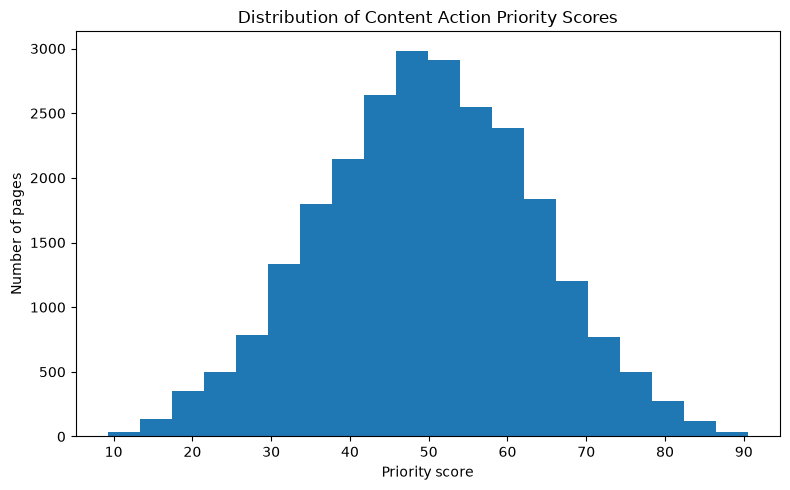

Figure saved to:
../../work/figures\action_priority_distribution.png


In [21]:
# Optional paper figure: distribution of action-priority scores

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    ranked_queue["priority_score"],
    bins=20
)

plt.xlabel("Priority score")
plt.ylabel("Number of pages")
plt.title("Distribution of Content Action Priority Scores")

plt.tight_layout()

FIGURE_DIR = "../../work/figures"

os.makedirs(
    FIGURE_DIR,
    exist_ok=True
)

FIGURE_PATH = os.path.join(
    FIGURE_DIR,
    "action_priority_distribution.png"
)

plt.savefig(
    FIGURE_PATH,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(FIGURE_PATH)

## Self-check

Before submission, confirm each point honestly:

- [ ] Every section contains Markdown reasoning and executable code.
- [ ] The ranked action queue was generated successfully.
- [ ] Every recommendation contains a reason code.
- [ ] Intended use and limitations are clearly stated.
- [ ] Human review is required before action.
- [ ] No-go automation cases are documented.
- [ ] Monitoring and retrain triggers are documented.
- [ ] The ranked queue was exported to `work/outputs/`.
- [ ] A reusable figure was exported to `work/figures/`.
- [ ] Claims use careful language such as observed, measured, directional, and decision-support.
- [ ] No client names, private queries, or unnecessary URLs are included.
- [ ] The notebook runs from top to bottom without errors.

In [22]:
# Final self-check

checks = {
    "ranked_queue_created": len(ranked_queue) > 0,
    "rank_column_present": "rank" in ranked_queue.columns,
    "priority_score_present": "priority_score" in ranked_queue.columns,
    "reason_code_present": "reason_code" in ranked_queue.columns,
    "human_review_present": "review_required" in ranked_queue.columns,
    "no_go_flag_present": "no_go_without_review" in ranked_queue.columns,
    "export_exists": os.path.exists(QUEUE_PATH),
}

self_check = pd.DataFrame(
    checks.items(),
    columns=["check", "passed"]
)

display(self_check)

if self_check["passed"].all():
    print("SELF-CHECK PASSED: all required notebook checks are complete.")
else:
    print("SELF-CHECK FAILED: review the failed checks above.")

,check,passed
0,ranked_queue_created,True
1,rank_column_present,True
2,priority_score_present,True
3,reason_code_present,True
4,human_review_present,True
5,no_go_flag_present,True
6,export_exists,True


SELF-CHECK PASSED: all required notebook checks are complete.
